# 고급 시각화

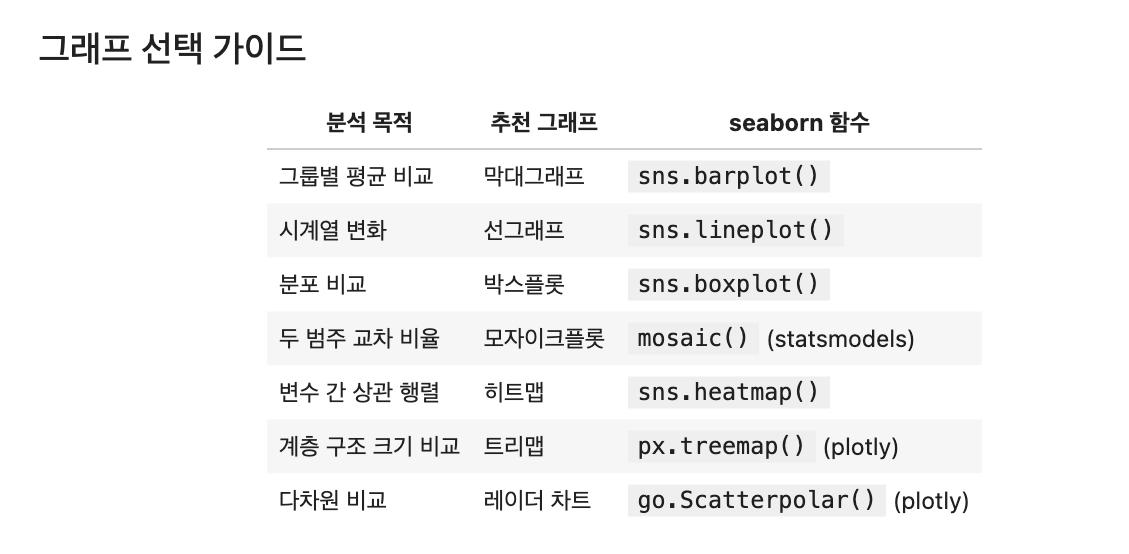

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료!')

환경 설정 완료!


### [1] seaborn - 범주형 데이터 : bar plot

tips 데이터 앞 3행:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


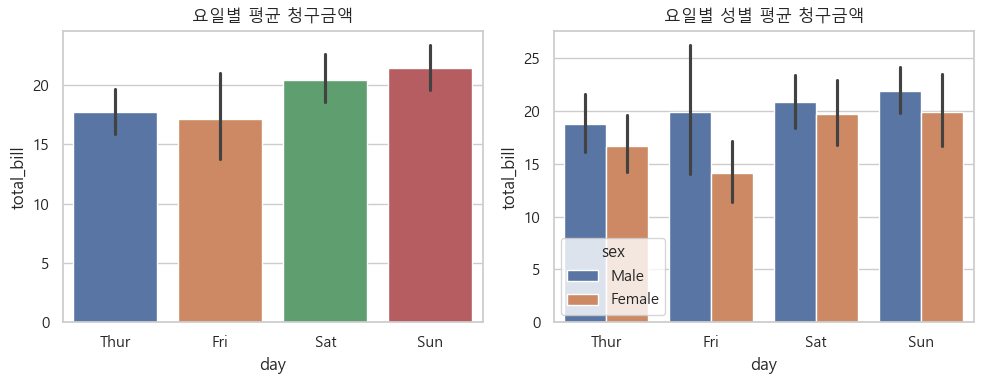

In [9]:
df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.head(3))

# set_theme에 font 설정 안하면 한글 깨짐 / default : 'sans-serif' (한글 지원 X)
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

# 글꼴 재설정
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

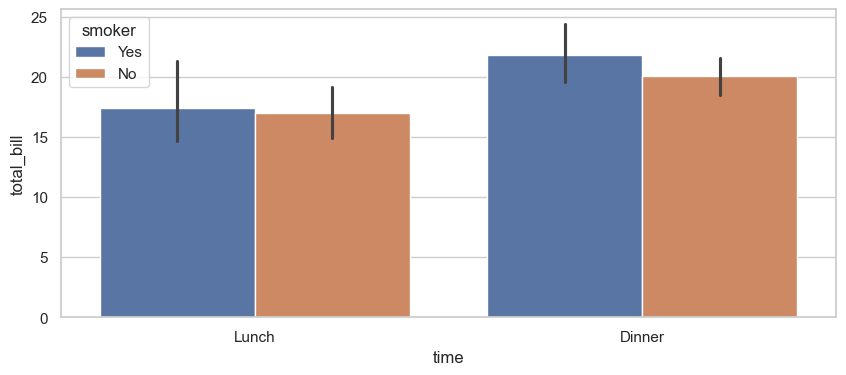

In [7]:
# 연습
sns.barplot(data = df, x = 'time', y = 'total_bill', estimator = 'mean',
           hue = 'smoker')

plt.show()

In [10]:
# [실습] seaborn - barplot : iris 품종별 평균 꽃잎 길이
iris_df = pd.read_csv('data/iris/iris.csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='species', ylabel='sepal_length'>

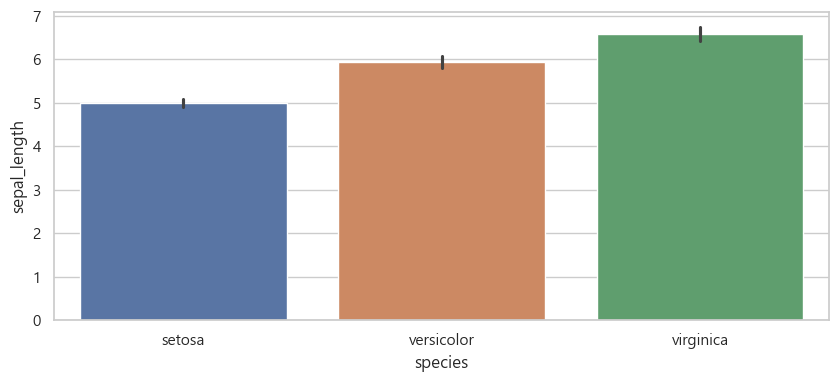

In [12]:
sns.barplot(data = iris_df, x = 'species', y = 'sepal_length', estimator = 'mean', hue = 'species')

### [2] seaborn lineplot - 월별 항공 탑승객

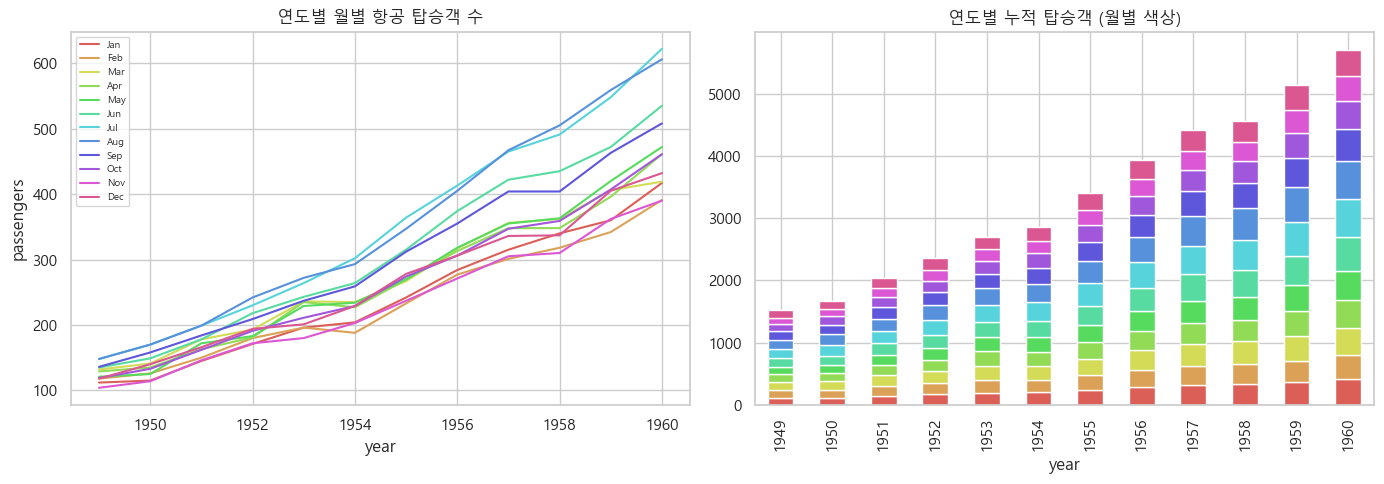

In [13]:
flights = sns.load_dataset('flights')
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.set_palette('hls', 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 선그래프
sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', ax=axes[0])
axes[0].set_title('연도별 월별 항공 탑승객 수')
axes[0].legend(loc='upper left', fontsize=7)

# 누적 막대그래프
df2 = flights.pivot_table(index='year', columns='month',
                          values='passengers', aggfunc='mean')
df2.plot.bar(stacked=True, ax=axes[1], legend=False)
axes[1].set_title('연도별 누적 탑승객 (월별 색상)')

plt.tight_layout()
plt.show()

### [3] seaborn boxplot - 서울 기온

In [19]:
temp_df = pd.read_csv('data/OBS_ASOS_DD_20250101.csv')
temp_df.head()
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        181 non-null    int64  
 1   지점명       181 non-null    object 
 2   일시        181 non-null    object 
 3   평균기온(°C)  181 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.8+ KB


In [21]:
temp_df['일시'] = pd.to_datetime(temp_df['일시'])
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   지점        181 non-null    int64         
 1   지점명       181 non-null    object        
 2   일시        181 non-null    datetime64[ns]
 3   평균기온(°C)  181 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 5.8+ KB


In [25]:
# [실습] 2016 ~ 2025년 까지의 평균 기온, 평균 습도를 boxplot으로 생성하여 한 행에 두개 그래프 생성
df = pd.read_csv('data/OBS_ASOS_MNH_20260623133953.csv')
df['일시'] = pd.to_datetime(df['일시'])
df['년도'] = df['일시'].dt.year
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   지점          120 non-null    int64         
 1   지점명         120 non-null    object        
 2   일시          120 non-null    datetime64[ns]
 3   평균기온(°C)    120 non-null    float64       
 4   평균상대습도(%)   120 non-null    int64         
 5   평균풍속(m/s)   120 non-null    float64       
 6   평균지면온도(°C)  120 non-null    float64       
 7   년도          120 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(2), object(1)
memory usage: 7.2+ KB


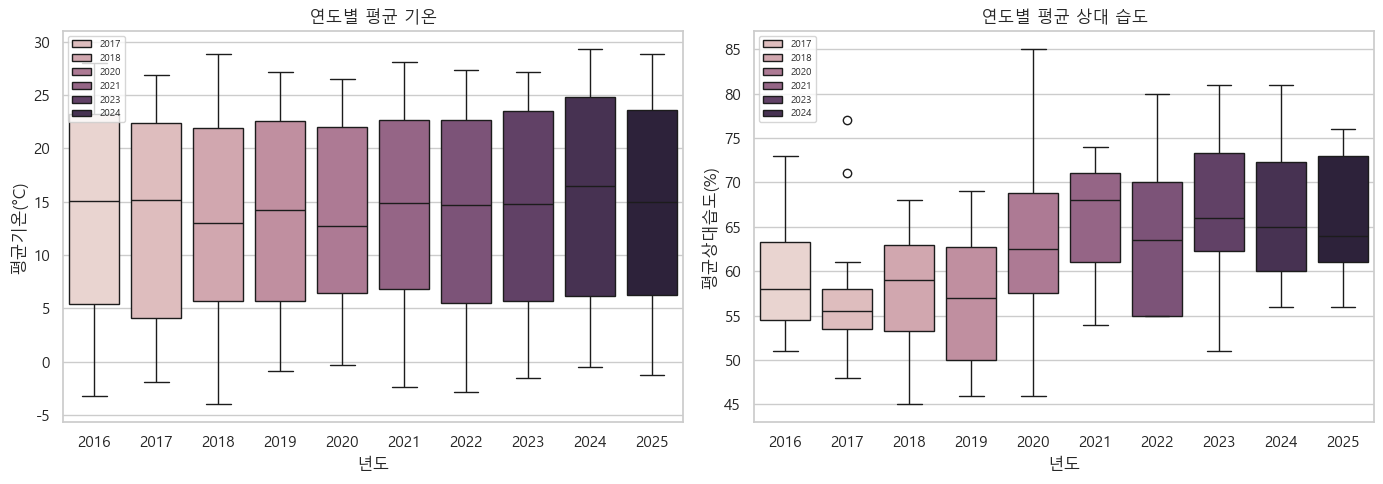

In [31]:
# 년도 기준 그룹
# x : 년도, y : 평균 기온, 평균 습도
# 년도별 박스 색상 다르게 표현

sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.set_palette('hls', 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='년도', y='평균기온(°C)',
             hue='년도', ax=axes[0])
axes[0].set_title('연도별 평균 기온')
axes[0].legend(loc='upper left', fontsize=7)

sns.boxplot(data=df, x='년도', y='평균상대습도(%)',
             hue='년도', ax=axes[1])
axes[1].set_title('연도별 평균 상대 습도')
axes[1].legend(loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['지점', '지점명', '일시', '평균기온(°C)', '평균상대습도(%)', '평균풍속(m/s)', '평균지면온도(°C)',
       '년도'],
      dtype='object')

### [예제 4] seaborn scatterplot 버블 차트 — 범죄율

In [33]:
df = pd.read_csv('data/crimeRatesByState2005.csv')
df.head()

,state,murder,forcible_rape,robbery,aggravated_assault,burglary,larceny_theft,motor_vehicle_theft,population
0,Alabama,8.2,34.3,141.4,247.8,953.8,2650.0,288.3,4545049
1,Alaska,4.8,81.1,80.9,465.1,622.5,2599.1,391.0,669488
2,Arizona,7.5,33.8,144.4,327.4,948.4,2965.2,924.4,5974834
3,Arkansas,6.7,42.9,91.1,386.8,1084.6,2711.2,262.1,2776221
4,California,6.9,26.0,176.1,317.3,693.3,1916.5,712.8,35795255


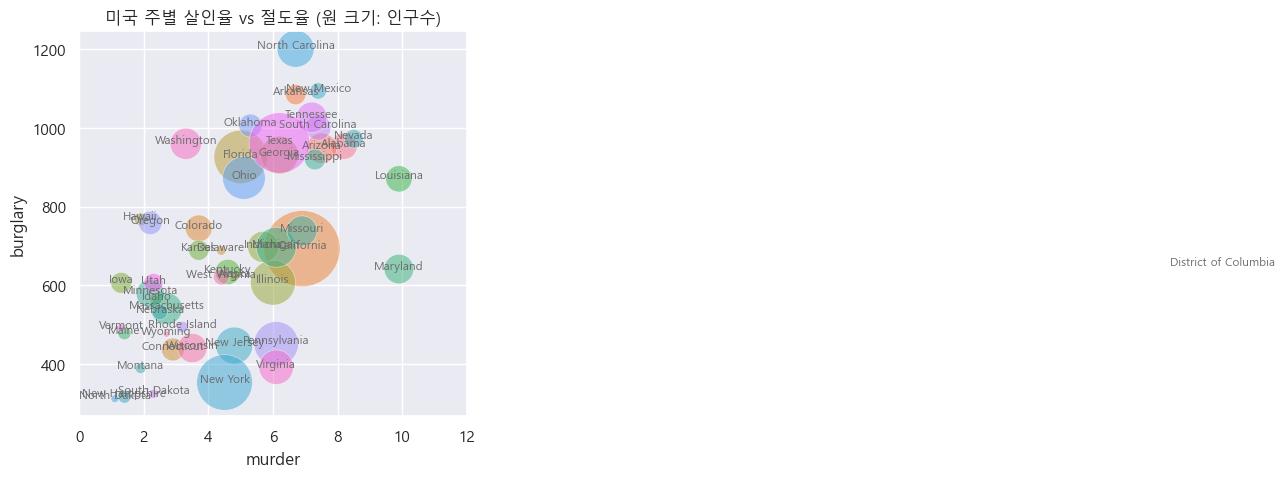

In [37]:
sns.set_theme(rc={'figure.figsize': (5, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.scatterplot(data=df, x='murder', y='burglary',
                size='population', sizes=(20, 3000),
                hue='state', alpha=0.5, legend=False)
plt.xlim(0, 12)
plt.title('미국 주별 살인율 vs 절도율 (원 크기: 인구수)')

# 주 이름 레이블
for i in range(len(df)):
    plt.text(df.murder.iloc[i], df.burglary.iloc[i], df.state.iloc[i],
             ha='center', size='x-small', color='dimgray')
plt.show()

### **[예제 5] mosaic plot — 타이타닉 생존율**

In [40]:
from statsmodels.graphics.mosaicplot import mosaic

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [41]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

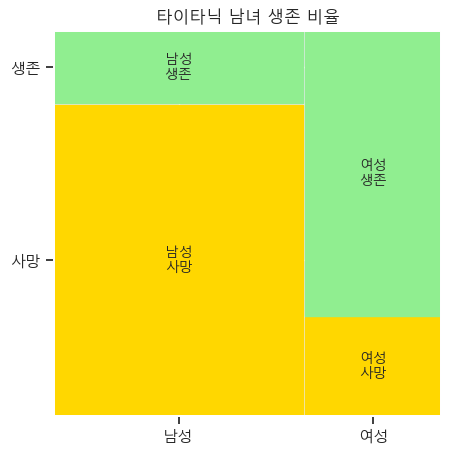

In [42]:
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'sex': {'male': '남성', 'female': '여성'}})

props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}

mosaic(data=df.sort_values('sex'),
       index=['sex', 'survived'],
       properties=props,
       axes_label=True,
       title='타이타닉 남녀 생존 비율')
plt.show()

### [예제 6] seaborn heatmap — 항공 탑승객

In [47]:
flights = sns.load_dataset('flights')

print(flights.shape)
print(flights.head())

(144, 3)
   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


In [49]:
pivot = flights.pivot_table(index='month', columns='year',
                            values='passengers', aggfunc='mean')
pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


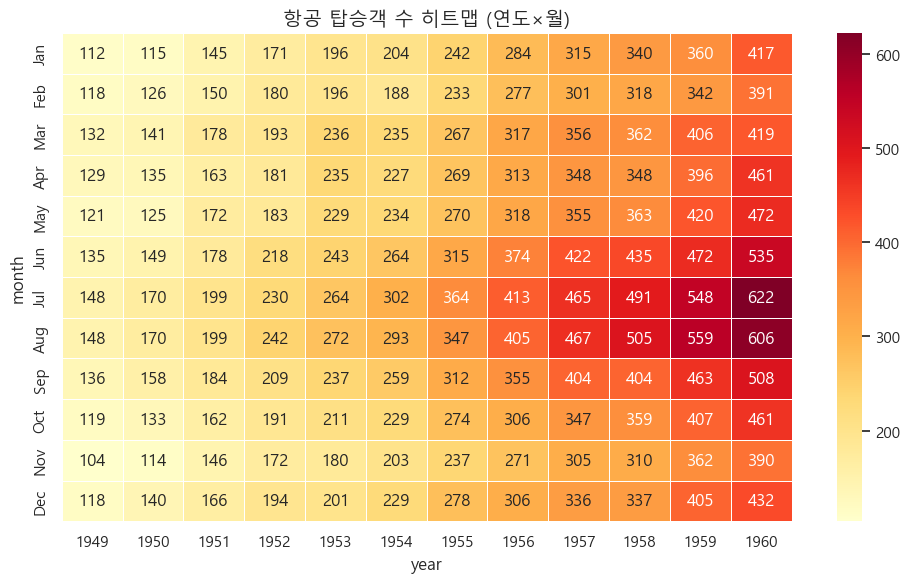

In [51]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('항공 탑승객 수 히트맵 (연도×월)', fontsize=14)
plt.tight_layout()
plt.show()

### [예제 7] plotly treemap — 국가별 인구/GNI

컬럼: ['iso3', 'country', 'continent', 'population', 'GNI']
  iso3  country      continent  population     GNI
0  BMU  Bermuda  North America       67837  106140
1  NOR   Norway         Europe     4676305  103630
2  QAT    Qatar           Asia      833285   92200


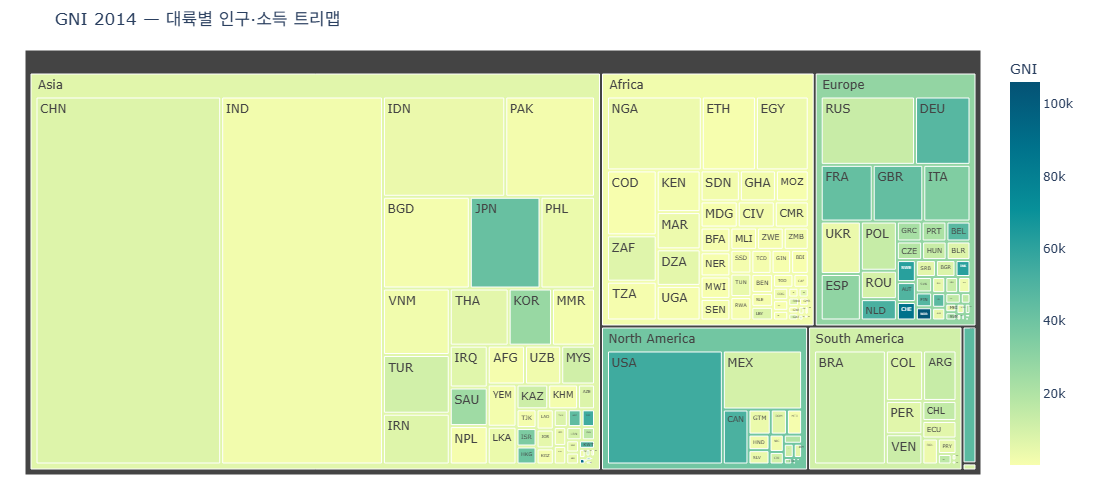

In [52]:
import plotly.express as px

df = pd.read_csv('data/GNI2014.csv')
print('컬럼:', df.columns.tolist())
print(df.head(3))

fig = px.treemap(
    data_frame=df,
    path=['continent', 'iso3'],   # 계층 구조: 대륙 → 국가
    values='population',          # 타일 면적
    color='GNI',                  # 색상 강도
    color_continuous_scale='Bluyl',
    title='GNI 2014 — 대륙별 인구·소득 트리맵'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25), width=800, height=500)
fig.show()

### [예제 8] 실전 분석 — 타이타닉 선실별 생존율 (mosaic + treemap)

In [53]:
from statsmodels.graphics.mosaicplot import mosaic
import plotly.express as px

df = sns.load_dataset('titanic')
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'pclass': {1: '1등실', 2: '2등실', 3: '3등실'}})

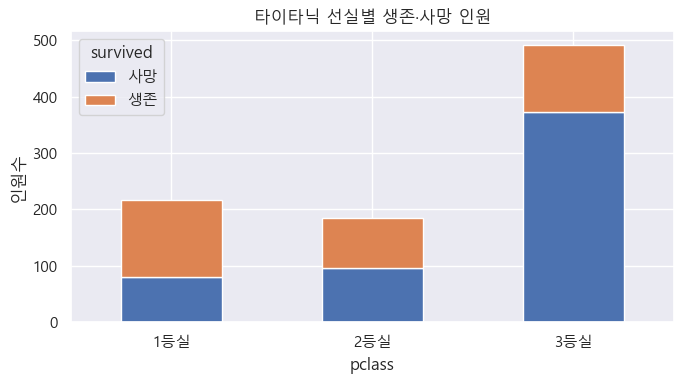

In [54]:
# 선실별 생존 수 막대그래프
df2 = df.pivot_table(index='pclass', columns='survived',
                     values='alone', aggfunc='count')
df2.plot.bar(stacked=True, figsize=(7, 4), rot=0,
             title='타이타닉 선실별 생존·사망 인원')
plt.ylabel('인원수')
plt.tight_layout()
plt.show()

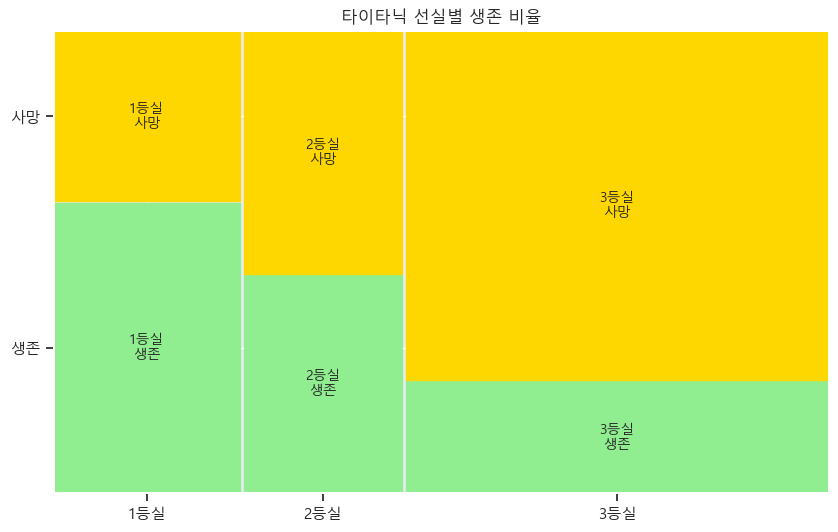

In [56]:
# 모자이크 플롯
props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}
mosaic(data=df.sort_values('pclass'), index=['pclass', 'survived'],
       properties=props, axes_label=True,
       title='타이타닉 선실별 생존 비율')
plt.show()

### **실습 2. heatmap — iris 상관계수 행렬 시각화**

**조건**

1. `iris.csv`의 수치형 컬럼 4개의 **상관계수 행렬**을 계산한다
2. `sns.heatmap()`으로 시각화한다
3. 각 셀에 상관계수 값을 표시하고(`annot=True`), 색상 팔레트는 `'coolwarm'`을 사용한다
4. 대각선 색상을 통해 완전 상관(`1.0`)임을 확인하고 Markdown 셀에 해석 한 줄을 작성한다

In [57]:
iris_df = pd.read_csv('data/iris/iris.csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [58]:
corr_matrix = iris_df.corr(numeric_only = True)
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


<Axes: >

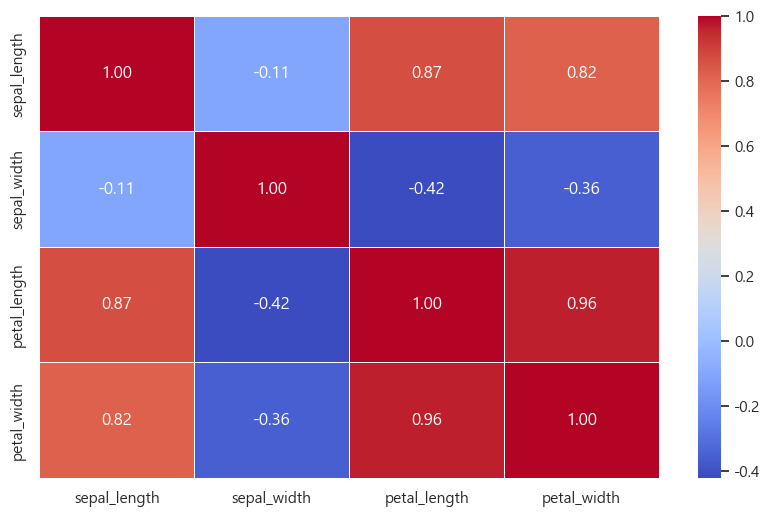

In [65]:
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

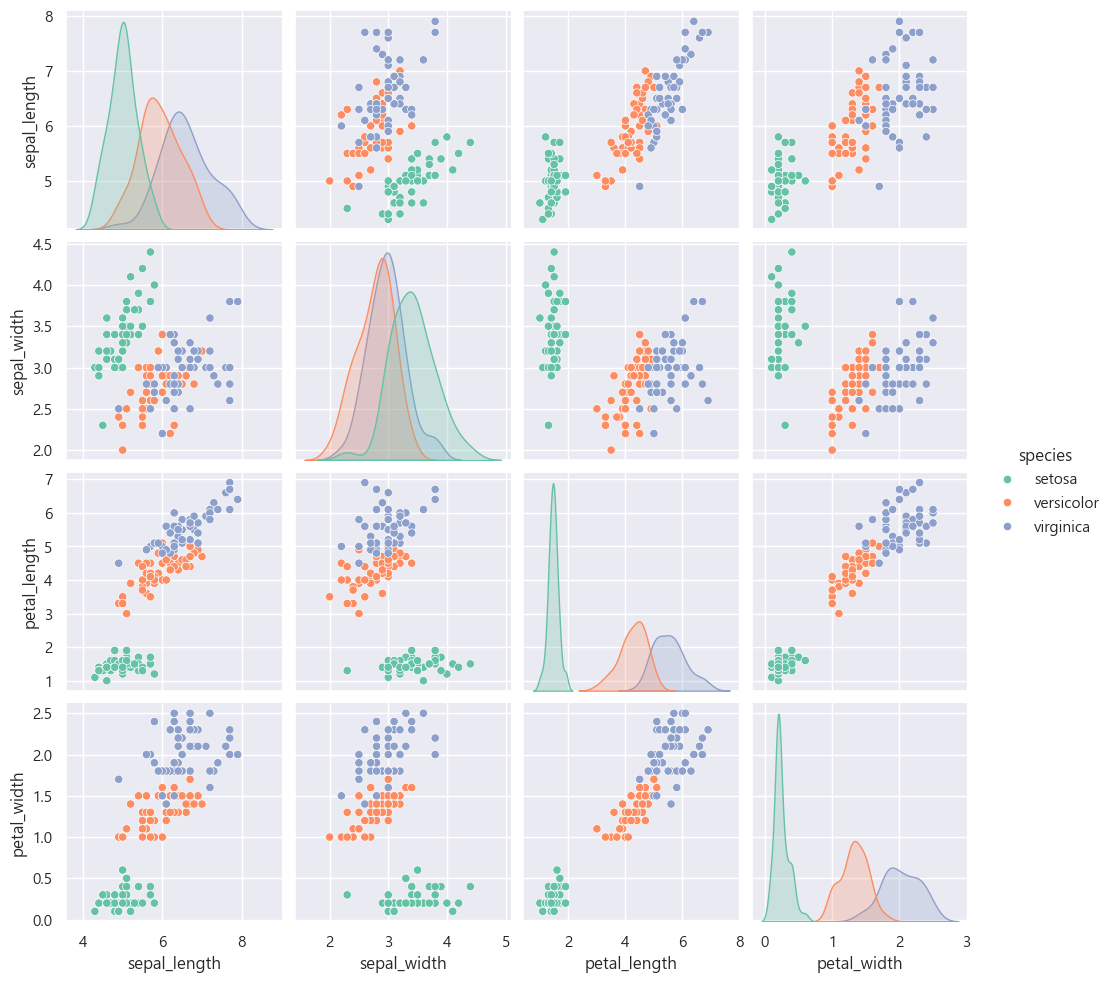

In [64]:
sns.pairplot(iris_df, hue='species', palette='Set2')
plt.show()

### heatmap - mpg 상관계수 행렬 시각화

In [73]:
mpg_df = pd.read_csv('data/auto-mpg.csv')
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [68]:
corr_matrix_mpg = mpg_df.corr(numeric_only = True)
corr_matrix_mpg

,mpg,cylinders,displacement,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.932824,-0.543684,-0.370164,-0.609409
weight,-0.831741,0.896017,0.932824,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.581024,0.205873,0.180662,1.000000


<Axes: >

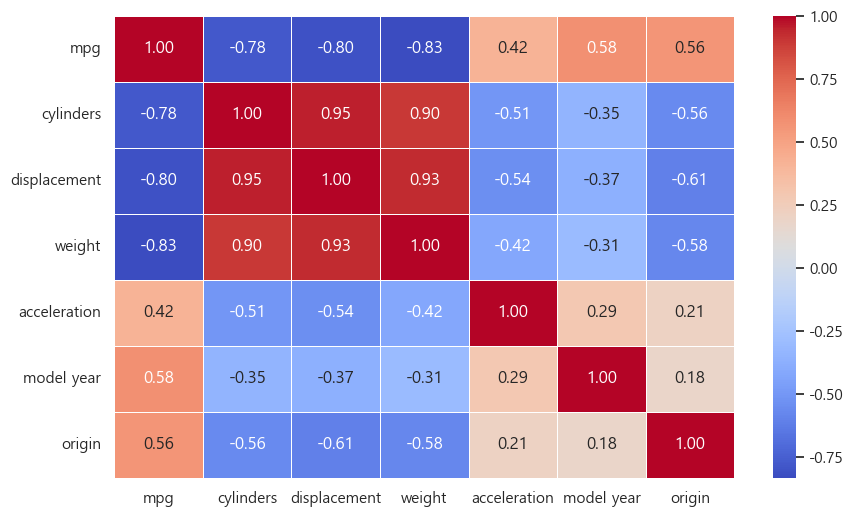

In [69]:
sns.heatmap(corr_matrix_mpg, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

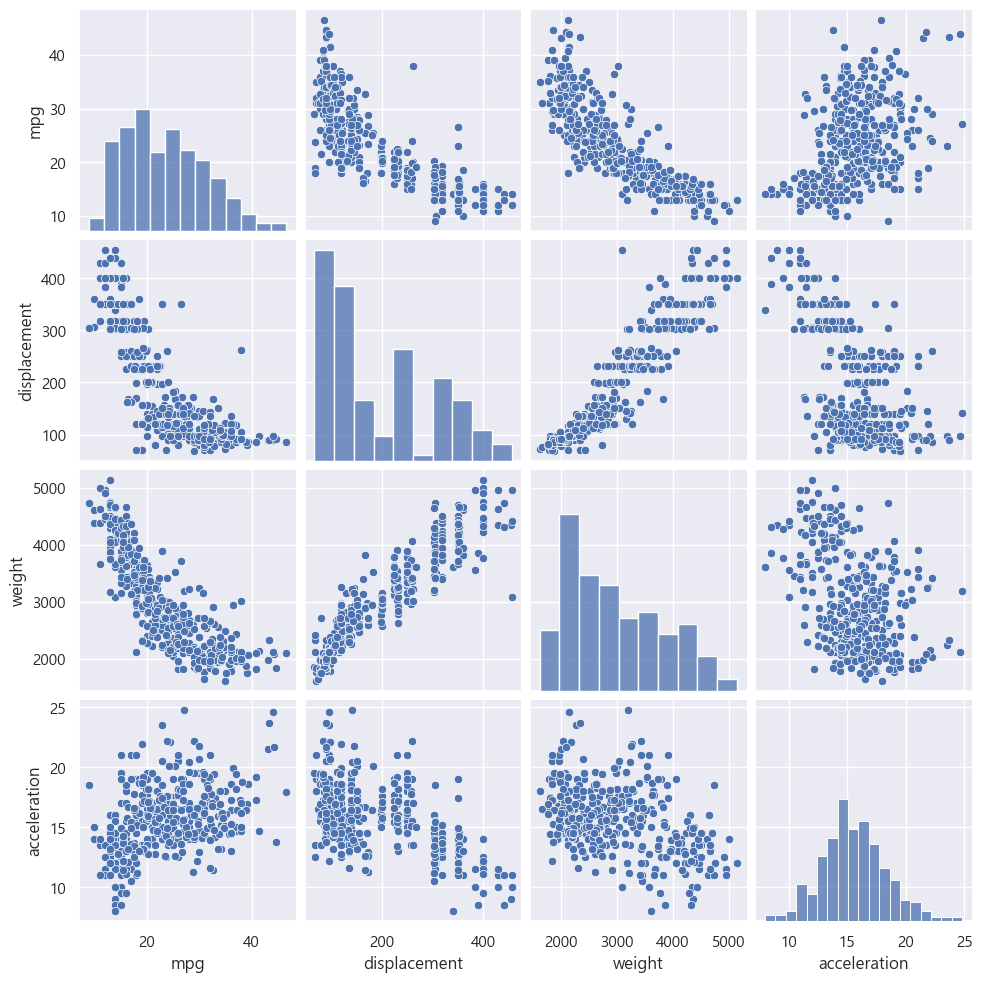

In [83]:
df_new = mpg_df.drop(['cylinders', 'origin', 'model year'], axis = 1)
sns.pairplot(df_new, palette='Set2')
plt.show()

### heatmap - Wine 상관계수 행렬 시각화

In [86]:
from sklearn.datasets import load_wine
wine = load_wine()

In [87]:
df = pd.DataFrame(
    wine.data,
    columns = wine.feature_names
)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [89]:
corr_matrix = df.corr()
corr_matrix

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


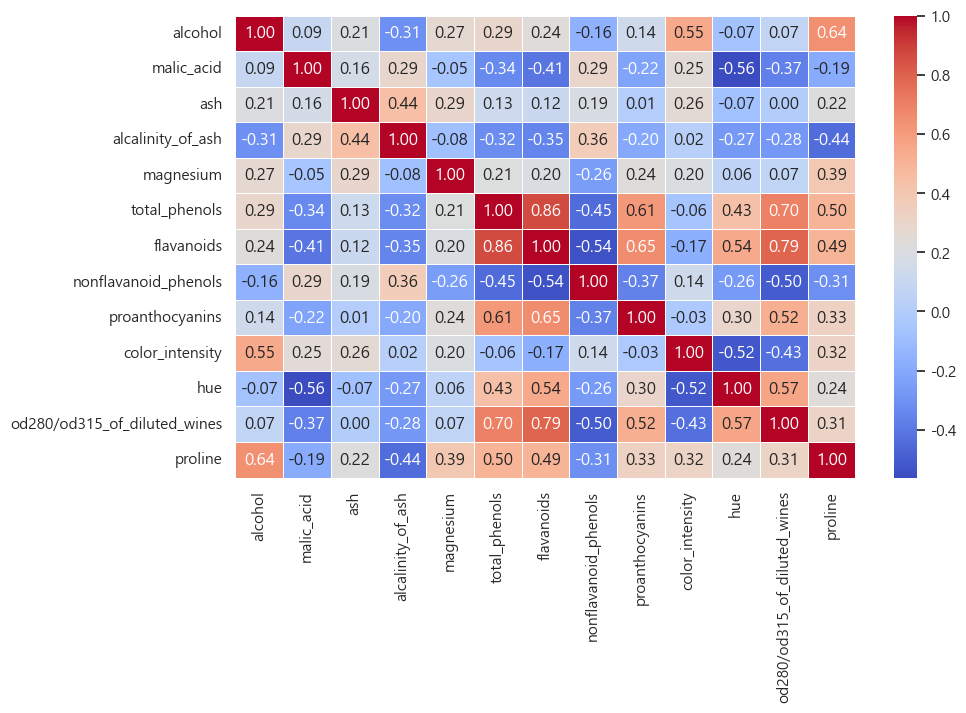

In [93]:


sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

In [95]:
corr_matrix[corr_matrix.values > 0.7]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193


### **실습 3. 타이타닉 성별×객실등급 생존 분석 (seaborn + mosaic)**

**조건** (seaborn 내장 titanic 사용)

1. 성별(`sex`)×객실등급(`pclass`)별 생존율(survived 평균)을 `barplot`으로 그린다
2. `sns.catplot()`을 이용해 col='sex'로 분할하여 객실등급별 생존율을 비교한다
3. 아래 해석을 Markdown 셀에 작성한다: 어떤 그룹의 생존율이 가장 높은가?

In [97]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


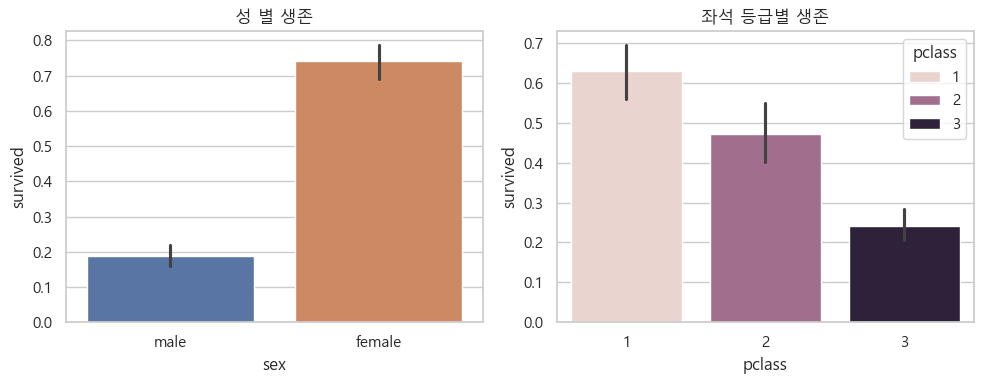

In [102]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2)

sns.barplot(data=df, x='sex', y='survived', estimator='mean',
            hue='sex', legend=False, ax=axes[0])
axes[0].set_title('성 별 생존')

sns.barplot(data=df, x='pclass', y='survived', estimator='mean',
            hue='pclass', ax=axes[1])
axes[1].set_title('좌석 등급별 생존')

plt.tight_layout()
plt.show()

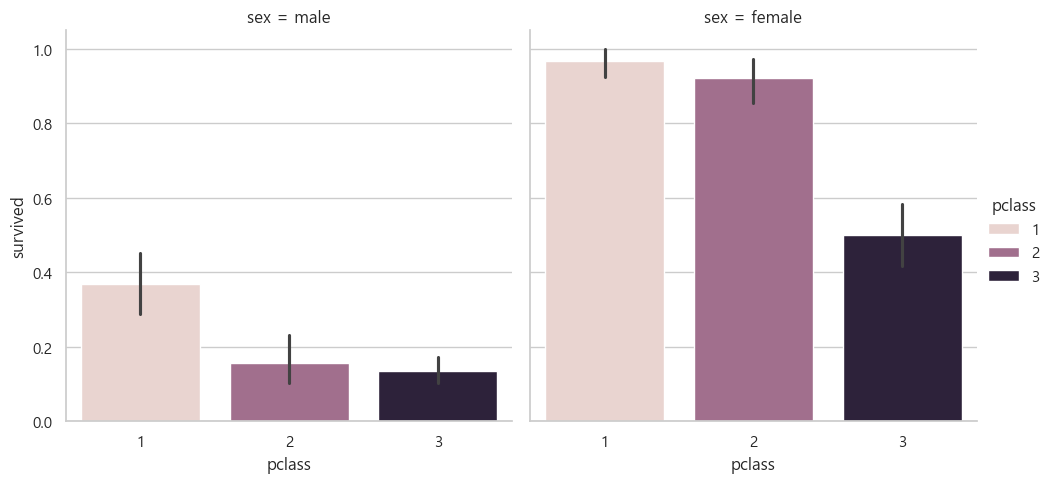

In [106]:
sns.catplot(
    data=df, 
    x='pclass', 
    y='survived', 
    hue = 'pclass',
    kind='bar', 
    col='sex'
)